In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("roqayyeh/concrete-strength-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/roqayyeh/concrete-strength-dataset/versions/1


In [ ]:
import os
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/roqayyeh/concrete-strength-dataset/versions/1/ConcreteStrengthData.csv
/root/.cache/kagglehub/datasets/roqayyeh/concrete-strength-dataset/versions/1/CocreteStrengthEDA.ipynb


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error, r2_score

!pip install lazypredict
from lazypredict.Supervised import LazyRegressor

In [ ]:
concrete_strength_data = pd.read_csv(path+'/ConcreteStrengthData.csv')
concrete_strength_data

,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
0,540.00,0.00,0.00,162.00,2.50,1040.00,676.00,28,79.99
1,540.00,0.00,0.00,162.00,2.50,1055.00,676.00,28,61.89
2,332.50,142.50,0.00,228.00,0.00,932.00,594.00,270,40.27
3,332.50,142.50,0.00,228.00,0.00,932.00,594.00,365,41.05
4,198.60,132.40,0.00,192.00,0.00,978.40,825.50,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.40,116.00,90.30,179.60,8.90,870.10,768.30,28,44.28
1026,322.20,0.00,115.60,196.00,10.40,817.90,813.40,28,31.18
1027,148.50,139.40,108.60,192.70,6.10,892.40,780.00,28,23.70
1028,159.10,186.70,0.00,175.60,11.30,989.60,788.90,28,32.77


In [ ]:
def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(concrete_strength_data)

data shape: (1030, 9)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
CementComponent,float64,0,0.00,25,278,1030,102.00,540.00,281.17,104.51,540.00,540.00,332.50
BlastFurnaceSlag,float64,0,0.00,25,185,1030,0.00,359.40,73.90,86.28,0.00,0.00,142.50
FlyAshComponent,float64,0,0.00,25,156,1030,0.00,200.10,54.19,64.00,0.00,0.00,0.00
WaterComponent,float64,0,0.00,25,195,1030,121.80,247.00,181.57,21.35,162.00,162.00,228.00
SuperplasticizerComponent,float64,0,0.00,25,111,1030,0.00,32.20,6.20,5.97,2.50,2.50,0.00
CoarseAggregateComponent,float64,0,0.00,25,284,1030,801.00,1145.00,972.92,77.75,1040.00,1055.00,932.00
FineAggregateComponent,float64,0,0.00,25,302,1030,594.00,992.60,773.58,80.18,676.00,676.00,594.00
AgeInDays,int64,0,0.00,25,14,1030,1.00,365.00,45.66,63.17,28.00,28.00,270.00
Strength,float64,0,0.00,25,845,1030,2.33,82.60,35.82,16.71,79.99,61.89,40.27


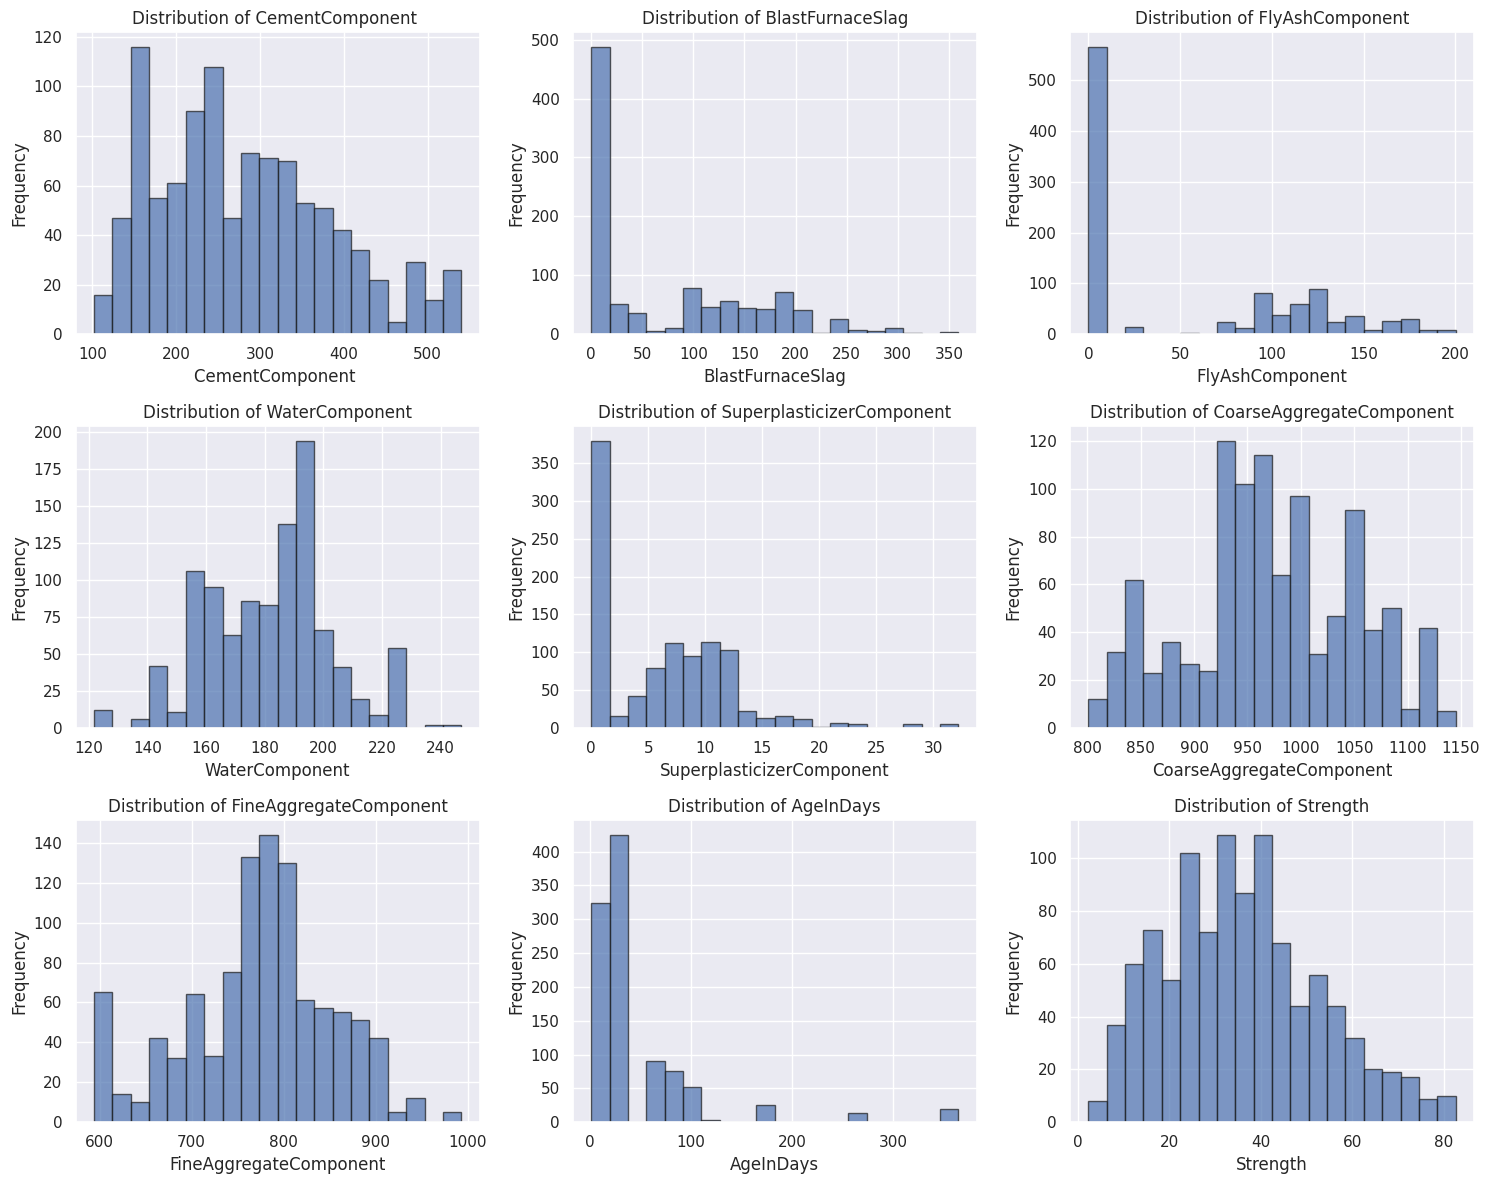

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = concrete_strength_data

plt.figure(figsize=(15, 12))

features = df.columns

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.hist(df[feature], bins=20, edgecolor='k', alpha=0.7)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


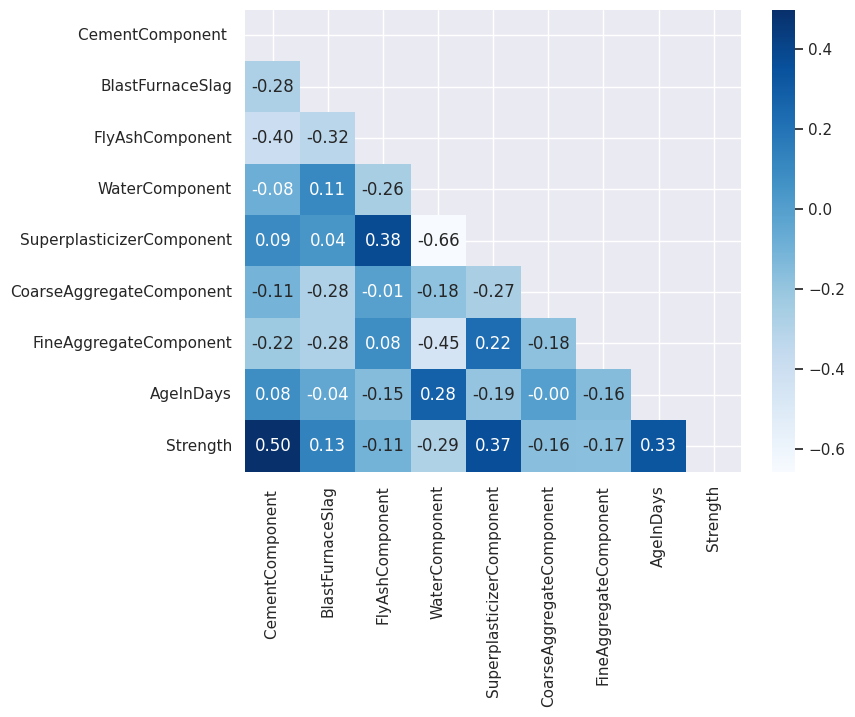

In [ ]:
corr = concrete_strength_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.set(rc={'figure.figsize': (8, 6)})
sns.heatmap(corr, mask = mask, cmap="Blues", annot=True, fmt=".2f")
plt.show()

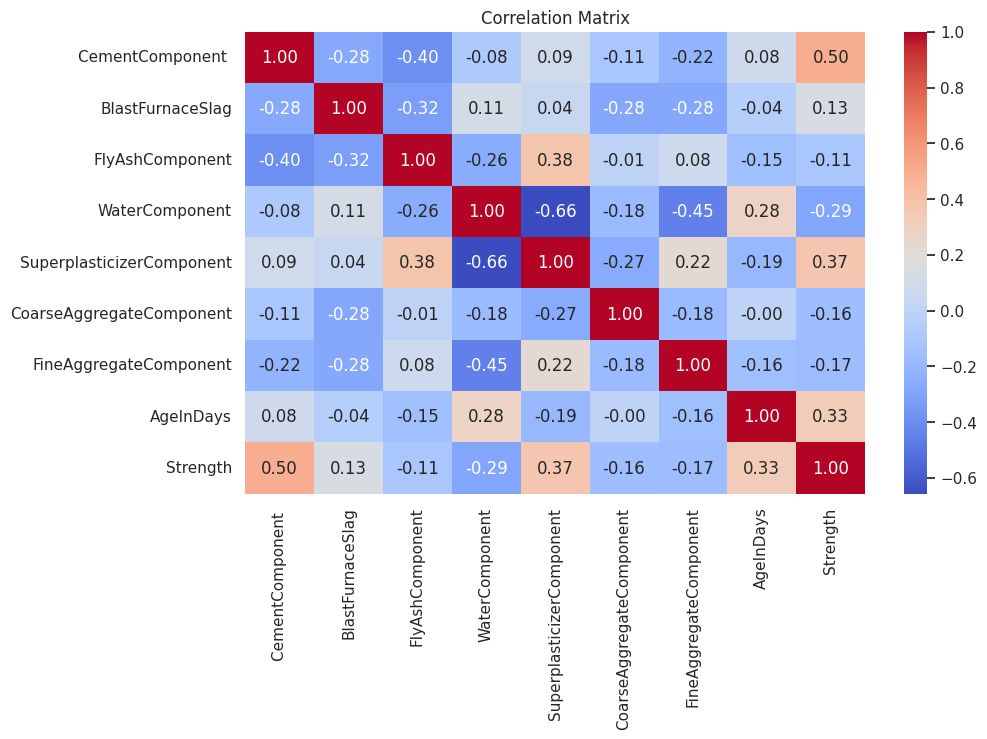

Correlations with Compressive Strength:
 Strength                     1.00
CementComponent              0.50
SuperplasticizerComponent    0.37
AgeInDays                    0.33
BlastFurnaceSlag             0.13
FlyAshComponent             -0.11
CoarseAggregateComponent    -0.16
FineAggregateComponent      -0.17
WaterComponent              -0.29
Name: Strength, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
target_corr = corr_matrix['Strength'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

print("Correlations with Compressive Strength:\n", target_corr)

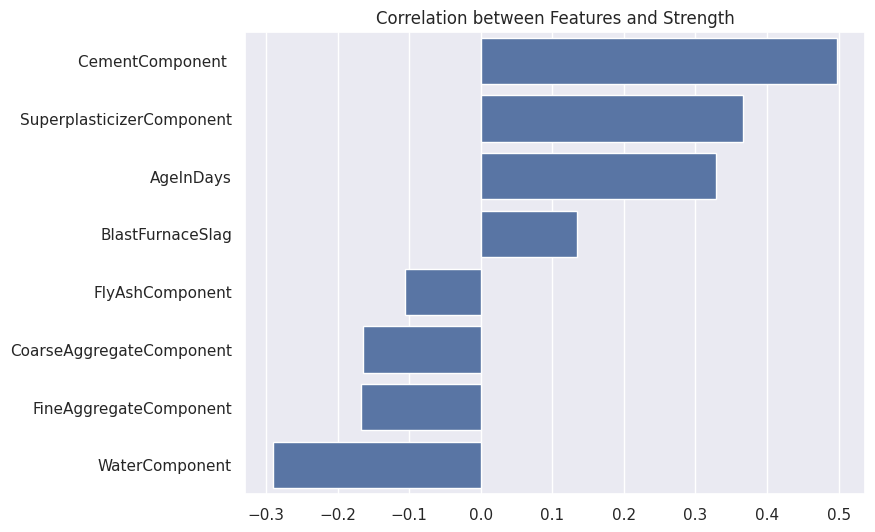

In [ ]:
# Correlation

limite = -1

data = concrete_strength_data.corr()["Strength"].sort_values(ascending=False)
indices = data.index
labels = []
corr = []
for i in range(1, len(indices)):
    if data[indices[i]]>limite:
        labels.append(indices[i])
        corr.append(data[i])
sns.barplot(x=corr, y=labels)
plt.title('Correlation between Features and Strength')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import torch

X = concrete_strength_data.drop(labels=['Strength'],axis=1)
Y = concrete_strength_data['Strength']

X =torch.from_numpy(X.values).float()
Y =torch.from_numpy(Y.values).float()

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape,Y_train.shape, Y_test.shape

(torch.Size([824, 8]),
 torch.Size([206, 8]),
 torch.Size([824]),
 torch.Size([206]))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class Net(nn.Module):
    def __init__(self,
                 hidden_n):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(8, hidden_n)
        self.fc2 = nn.Linear(hidden_n, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
model = Net(16)

learning_rate = 0.01
epochs = 50

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate)

train_loss_16 = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_16.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [ ]:
model = Net(32)

learning_rate = 0.01
epochs = 50

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate)

train_loss_32 = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_32.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


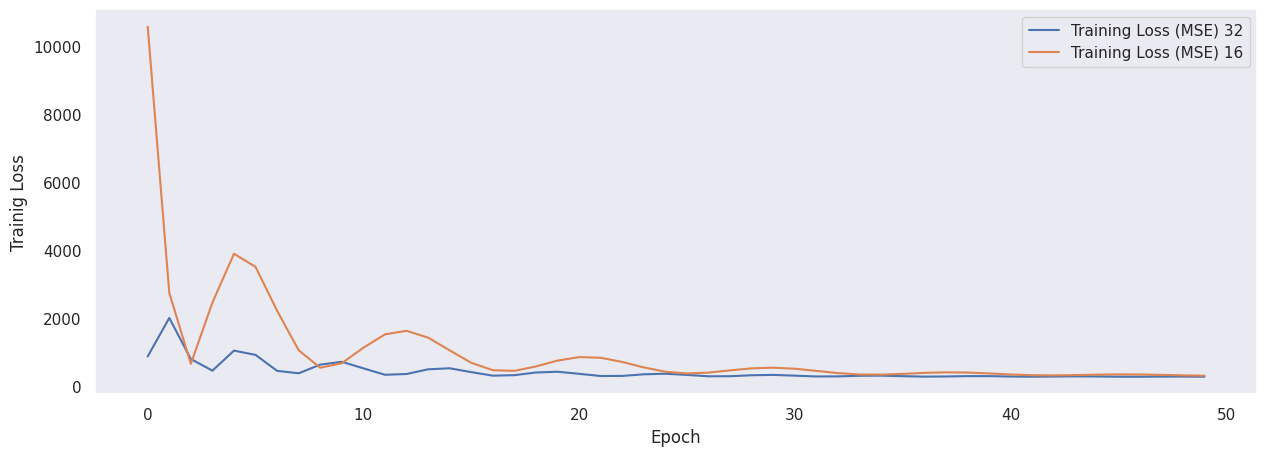

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(train_loss_32, label='Training Loss (MSE) 32')
plt.plot(train_loss_16, label='Training Loss (MSE) 16')
plt.xlabel('Epoch')
plt.ylabel('Trainig Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)

    y_pred_np = y_pred.numpy()
    y_test_np = Y_test.numpy()


    mse = mean_squared_error(y_test_np, y_pred_np)
    mae = mean_absolute_error(y_test_np, y_pred_np)

    print(f'\nTest MSE: {mse:.4f}')
    print(f'Test MAE: {mae:.4f}')

    mse_torch = nn.MSELoss()(y_pred, Y_test).item()
    mae_torch = nn.L1Loss()(y_pred, Y_test).item()
    print(f'\nTest MSE (PyTorch): {mse_torch:.4f}')
    print(f'Test MAE (PyTorch): {mae_torch:.4f}')


Test MSE: 290.0703
Test MAE: 13.8056

Test MSE (PyTorch): 264.2209
Test MAE (PyTorch): 13.2092


3

In [ ]:
model = Net(32)

learning_rate = 0.001
epochs = 100

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate)
train_loss100 = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss100.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

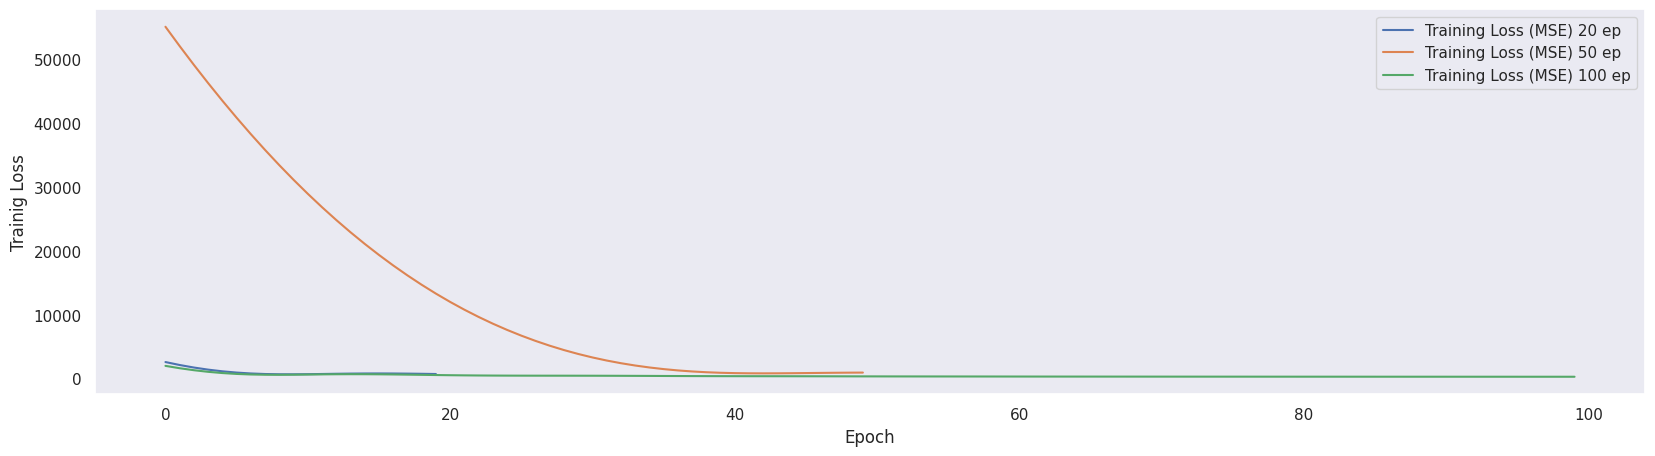

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(train_loss20, label='Training Loss (MSE) 20 ep')
plt.plot(train_loss50, label='Training Loss (MSE) 50 ep')
plt.plot(train_loss100, label='Training Loss (MSE) 100 ep')
plt.xlabel('Epoch')
plt.ylabel('Trainig Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
model = Net(32)
learning_rate = 0.001
epochs = 100

criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate)
train_loss_huber = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_huber.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [ ]:
model = Net(32)

learning_rate = 0.001
epochs = 100

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate)
train_loss_mse = []
for epoch in range(epochs):

        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_mse.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
model = Net(32)

learning_rate = 0.001
epochs = 100

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate)
train_loss_mae = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_mae.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

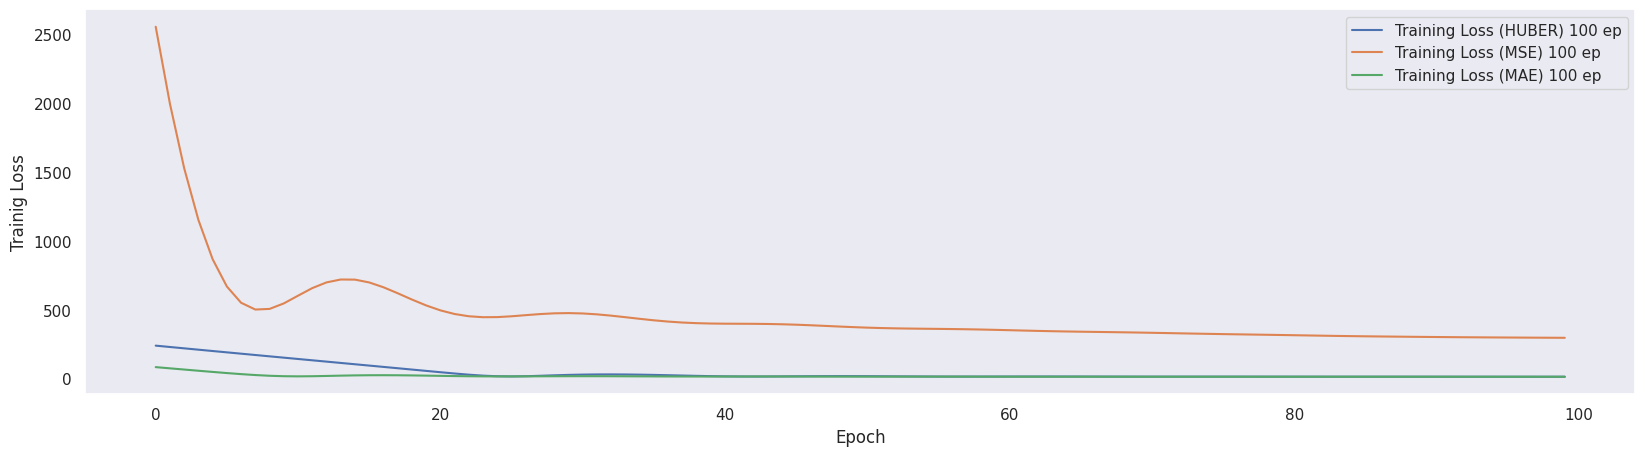

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(train_loss_huber, label='Training Loss (HUBER) 100 ep')
plt.plot(train_loss_mse, label='Training Loss (MSE) 100 ep')
plt.plot(train_loss_mae, label='Training Loss (MAE) 100 ep')
plt.xlabel('Epoch')
plt.ylabel('Trainig Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
model = Net(32)
learning_rate = 0.001
epochs = 100

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),
                       lr=learning_rate)
train_loss_SGD = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_SGD.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [ ]:
model = Net(32)

learning_rate = 0.001
epochs = 100

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate)
train_loss_adam = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_adam.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
model = Net(32)
learning_rate = 0.001
epochs = 100

criterion = nn.MSELoss()
optimizer = optim.RMSprop(model.parameters(),
                       lr=learning_rate)
train_loss_RMS = []
for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        train_loss_RMS.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


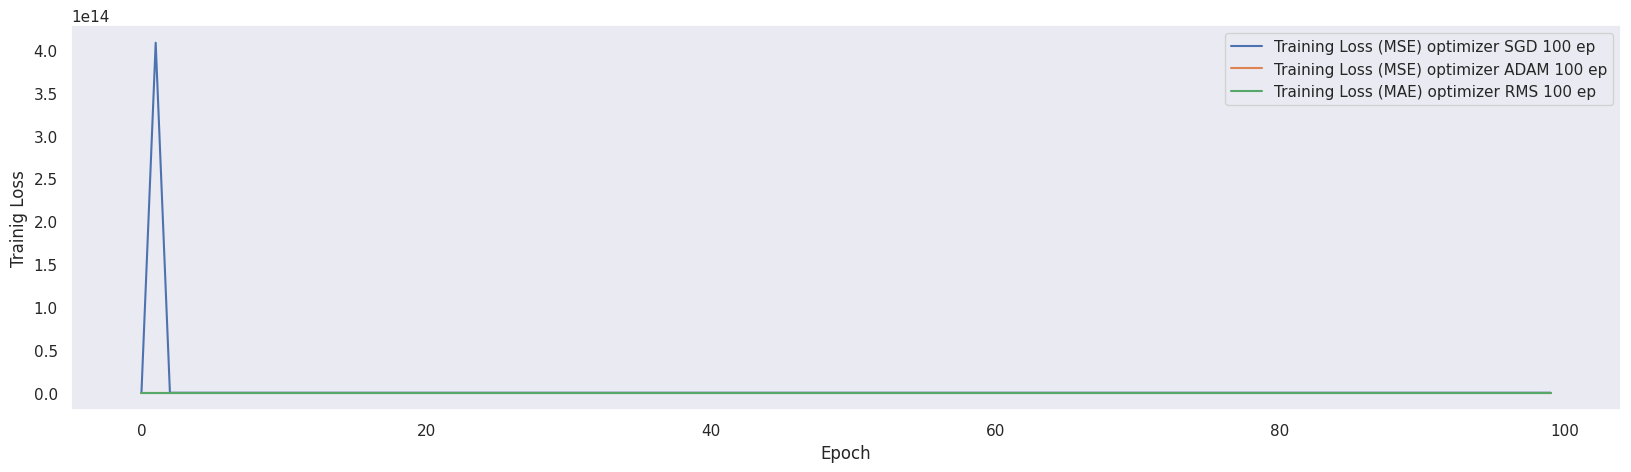

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(train_loss_SGD, label='Training Loss (MSE) optimizer SGD 100 ep')
plt.plot(train_loss_adam, label='Training Loss (MSE) optimizer ADAM 100 ep')
plt.plot(train_loss_RMS, label='Training Loss (MAE) optimizer RMS 100 ep')
plt.xlabel('Epoch')
plt.ylabel('Trainig Loss')
plt.legend()
plt.grid()
plt.show()